# SNR Comparison

Compare SNR distributions and summary statistics for Macaque, MoisesDB, and Bandit EV results.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# File paths
macaque_path = '../data/logs/e2e/test/2JB0ZX/lightning_logs/version_0/metrics.csv'
moisesdb_path = '../data/logs/e2e/test/7P21AG/lightning_logs/version_0/metrics.csv'
bandit_ev_path = '../third_party/query-bandit/reproducibility/results/query/bandit_ev.csv'

# Helper to extract all SNR columns for model results
def get_snr_cols(df):
    # Select all columns ending with '/snr/SafeSignalNoiseRatio'
    return [col for col in df.columns if col.endswith('/snr/SafeSignalNoiseRatio')]

def load_and_standarize(path, label):
    df = pd.read_csv(path)
    if label in ['Macaque', 'MoisesDB']:
        snr_cols = get_snr_cols(df)
        # Stack all SNR values from all instrument columns
        snr_values = pd.concat([df[col] for col in snr_cols], ignore_index=True)
        snr_values = snr_values[pd.notnull(snr_values) & np.isfinite(snr_values)]
        out = pd.DataFrame({'SNR': snr_values.astype(float), 'dataset': label})
        return out
    elif label == 'Bandit EV':
        snr_col = 'snr' if 'snr' in df.columns else df.columns[0]
        snr_values = df[snr_col]
        snr_values = snr_values[pd.notnull(snr_values) & np.isfinite(snr_values)]
        out = pd.DataFrame({'SNR': snr_values.astype(float), 'dataset': label})
        return out
    else:
        raise ValueError(f"Unknown label: {label}")

macaque = load_and_standarize(macaque_path, 'Macaque')
moisesdb = load_and_standarize(moisesdb_path, 'MoisesDB')
bandit_ev = load_and_standarize(bandit_ev_path, 'Bandit EV')

all_results = pd.concat([macaque, moisesdb, bandit_ev], ignore_index=True)


KeyError: 'test/target/snr/SafeSignalNoiseRatio'

In [5]:
# Summary statistics
summary = all_results.groupby('dataset')['SNR'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])
display(summary)

,mean,median,std,min,max,count
dataset,,,,,,
Bandit EV,4.240059,3.059238,5.118803,-14.719251,18.090504,3010
Macaque,-113.756178,-119.842258,10.786614,-119.999893,-76.934586,200
MoisesDB,-77.794770,-77.874119,13.915206,-104.240974,-56.836754,22


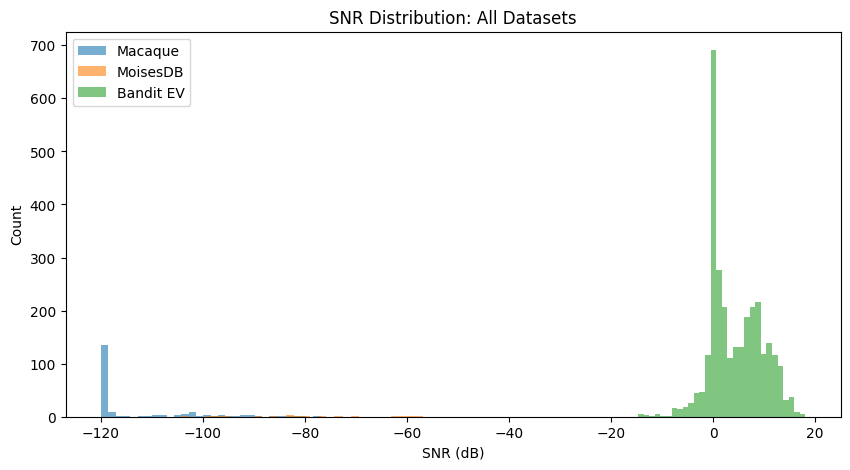

In [6]:
# Plot distributions
plt.figure(figsize=(10,5))
for dataset in all_results['dataset'].unique():
    subset = all_results[all_results['dataset'] == dataset]
    plt.hist(subset['SNR'], bins=30, alpha=0.6, label=dataset)
plt.xlabel('SNR (dB)')
plt.ylabel('Count')
plt.title('SNR Distribution: All Datasets')
plt.legend()
plt.show()